# Feature engineering — od cech czasowych po cechy przestrzenne

Notebook krok po kroku: jak budować nowe cechy z surowych danych, kiedy
dana transformacja faktycznie pomaga (a kiedy jest zbędna dla konkretnego
typu modelu), i jak robić to bez wprowadzania data leakage — nawiązując
wprost do poprzedniego notebooka o `Pipeline` w scikit-learn.

Jedna zasada wraca w kilku miejscach: **feature engineering z użyciem
statystyk policzonych na targecie (target encoding, agregacje po grupie)
jest tak samo podatny na data leakage jak skalowanie przed podziałem
train/test** — sekcja 4 i 10 pokazują to na konkretnym przykładzie.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import PowerTransformer, KBinsDiscretizer, FunctionTransformer
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid")

## 1. Po co feature engineering — krótkie uzasadnienie

Model uczy się wzorców w danych, ale niektóre wzorce są dla niego "trudne
do zobaczenia" w surowej postaci — np. cykliczność miesiąca, odległość
geograficzna, silnie skośny rozkład. Dobrze zbudowana cecha potrafi
poprawić model bardziej niż zmiana algorytmu — w praktyce analitycznej
zwykle warto najpierw dopracować cechy, dopiero potem próbować
bardziej złożonych modeli (nawiązanie do sekcji 10 poprzedniego notebooka).

## 2. Cechy czasowe — rozkład na komponenty i kodowanie cykliczne

### a) Podstawowe komponenty z daty

In [2]:
df_transakcje = pd.DataFrame({
    "data_transakcji": pd.date_range("2024-01-01", periods=400, freq="18h"),
    "kwota": rng.gamma(2, 150, 400).round(2),
})

df_transakcje["rok"] = df_transakcje["data_transakcji"].dt.year
df_transakcje["miesiac"] = df_transakcje["data_transakcji"].dt.month
df_transakcje["dzien_tygodnia"] = df_transakcje["data_transakcji"].dt.dayofweek   # 0=poniedzialek
df_transakcje["godzina"] = df_transakcje["data_transakcji"].dt.hour
df_transakcje["czy_weekend"] = df_transakcje["dzien_tygodnia"].isin([5, 6]).astype(int)

df_transakcje.head()

,data_transakcji,kwota,rok,miesiac,dzien_tygodnia,godzina,czy_weekend
0,2024-01-01 00:00:00,313.77,2024,1,0,0,0
1,2024-01-01 18:00:00,425.30,2024,1,0,18,0
2,2024-01-02 12:00:00,275.58,2024,1,1,12,0
3,2024-01-03 06:00:00,246.76,2024,1,2,6,0
4,2024-01-04 00:00:00,461.89,2024,1,3,0,0


### b) Kodowanie cykliczne (sin/cos) — dlaczego zwykłe liczby mylą model

Miesiąc zakodowany jako liczba 1-12 sugeruje modelowi, że grudzień (12) i
styczeń (1) są od siebie odległe — a w rzeczywistości to sąsiednie miesiące.
Kodowanie sin/cos umieszcza wartości na okręgu, gdzie odległość
"opakowuje się" poprawnie.

In [3]:
# porównanie odległości: zwykłe liczby vs kodowanie cykliczne
grudzien, styczen = 12, 1

roznica_liczbowa = abs(grudzien - styczen)
print(f"Różnica 'zwykła' (grudzień vs styczeń): {roznica_liczbowa}  <- wygląda jakby były bardzo odległe")

def do_sin_cos(wartosc, okres):
    return np.sin(2 * np.pi * wartosc / okres), np.cos(2 * np.pi * wartosc / okres)

sin_XII, cos_XII = do_sin_cos(grudzien, 12)
sin_I, cos_I = do_sin_cos(styczen, 12)
odleglosc_cykliczna = np.sqrt((sin_XII - sin_I) ** 2 + (cos_XII - cos_I) ** 2)
print(f"Różnica po kodowaniu cyklicznym: {odleglosc_cykliczna:.3f}  <- poprawnie blisko siebie")

Różnica 'zwykła' (grudzień vs styczeń): 11  <- wygląda jakby były bardzo odległe
Różnica po kodowaniu cyklicznym: 0.518  <- poprawnie blisko siebie


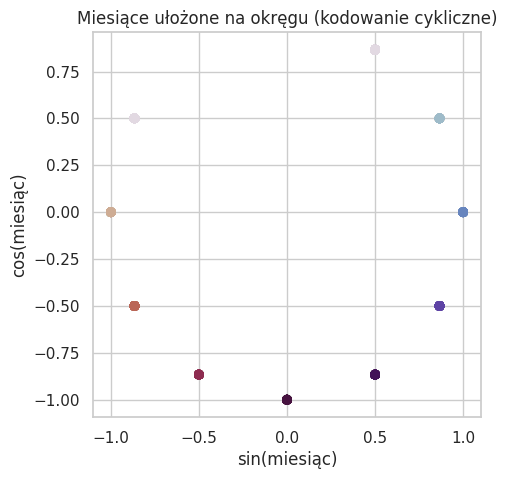

In [4]:
df_transakcje["miesiac_sin"] = np.sin(2 * np.pi * df_transakcje["miesiac"] / 12)
df_transakcje["miesiac_cos"] = np.cos(2 * np.pi * df_transakcje["miesiac"] / 12)
df_transakcje["godzina_sin"] = np.sin(2 * np.pi * df_transakcje["godzina"] / 24)
df_transakcje["godzina_cos"] = np.cos(2 * np.pi * df_transakcje["godzina"] / 24)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df_transakcje["miesiac_sin"], df_transakcje["miesiac_cos"], c=df_transakcje["miesiac"], cmap="twilight")
ax.set_title("Miesiące ułożone na okręgu (kodowanie cykliczne)")
ax.set_xlabel("sin(miesiąc)")
ax.set_ylabel("cos(miesiąc)")
plt.show()

Kodowanie cykliczne ma znaczenie głównie dla modeli, które "widzą"
odległość między wartościami wprost (regresja liniowa, KNN, sieci
neuronowe) — dla modeli opartych na podziałach (drzewa, lasy losowe,
gradient boosting) zwykły numer miesiąca zwykle wystarcza, bo drzewo może
dowolnie dzielić zakres wartości.

## 3. Cechy "czas od zdarzenia" (recency)

Bardzo częsty typ cechy w danych biznesowych: ile czasu minęło od ostatniej
aktywności. Liczysz to względem ustalonego punktu odniesienia (np. daty
generowania raportu / daty "dziś" w danych), **nigdy względem bieżącej
daty systemowej w produkcji** — inaczej ta sama transakcja miałaby inną
wartość cechy w zależności od tego, kiedy model jest uruchamiany.

In [5]:
df_klienci = pd.DataFrame({
    "klient_id": range(1, 11),
    "ostatni_zakup": pd.to_datetime([
        "2025-01-15", "2025-06-01", "2025-08-20", "2024-11-30", "2025-09-01",
        "2025-07-10", "2025-02-14", "2025-08-28", "2025-05-05", "2025-08-15",
    ]),
})

data_odniesienia = pd.Timestamp("2025-09-01")   # np. data wygenerowania raportu — STAŁA, nie pd.Timestamp.now()

df_klienci["dni_od_ostatniego_zakupu"] = (data_odniesienia - df_klienci["ostatni_zakup"]).dt.days
df_klienci

,klient_id,ostatni_zakup,dni_od_ostatniego_zakupu
0,1,2025-01-15,229
1,2,2025-06-01,92
2,3,2025-08-20,12
3,4,2024-11-30,275
4,5,2025-09-01,0
5,6,2025-07-10,53
6,7,2025-02-14,199
7,8,2025-08-28,4
8,9,2025-05-05,119
9,10,2025-08-15,17


## 4. Kodowanie zmiennych kategorycznych — cztery podejścia

Poprzedni notebook pokazywał one-hot encoding jako domyślny wybór — tu
trzy dodatkowe warianty i kiedy sięgać po który.

| Metoda | Kiedy stosować | Ryzyko |
|---|---|---|
| **One-hot** | mało kategorii (≲15), brak naturalnej kolejności | eksplozja liczby kolumn przy wysokiej kardynalności |
| **Ordinal** | kategorie mają naturalną kolejność (np. "niski/średni/wysoki") | sugeruje kolejność tam, gdzie jej nie ma — używaj tylko gdy kolejność faktycznie istnieje |
| **Frequency encoding** | dużo kategorii (miasta, kody pocztowe), kolejność nieistotna | dwie różne kategorie o tej samej częstości stają się nieodróżnialne |
| **Target/mean encoding** | bardzo dużo kategorii, silny związek z targetem | **wysokie ryzyko data leakage** — wymaga poprawnej implementacji (patrz niżej) |

In [6]:
df_kat = pd.DataFrame({
    "poziom_wyksztalcenia": ["podstawowe", "srednie", "wyzsze", "srednie", "wyzsze"],
    "miasto": ["Warszawa", "Radom", "Warszawa", "Krakow", "Radom"],
})

# ordinal — jawnie zdefiniowana kolejność (NIE alfabetyczna!)
kolejnosc = {"podstawowe": 0, "srednie": 1, "wyzsze": 2}
df_kat["wyksztalcenie_ordinal"] = df_kat["poziom_wyksztalcenia"].map(kolejnosc)

# frequency encoding — zamiana kategorii na jej częstość występowania
czestosci = df_kat["miasto"].value_counts(normalize=True)
df_kat["miasto_frequency"] = df_kat["miasto"].map(czestosci)

df_kat

,poziom_wyksztalcenia,miasto,wyksztalcenie_ordinal,miasto_frequency
0,podstawowe,Warszawa,0,0.4
1,srednie,Radom,1,0.4
2,wyzsze,Warszawa,2,0.4
3,srednie,Krakow,1,0.2
4,wyzsze,Radom,2,0.4


### Target encoding — POPRAWNIE, z walidacją krzyżową wewnątrz treningu

Naiwna wersja (`df.groupby("kategoria")["target"].mean()` na CAŁYM zbiorze
i zmapowanie z powrotem) to podręcznikowy przykład data leakage — każdy
wiersz "widzi" swój własny target zaszyty w wartości cechy. Poprawna wersja
liczy średnią z **innych foldów**, nie z tego samego wiersza.

In [7]:
n = 300
liczba_kategorii = 60   # dużo kategorii, mało obserwacji na kategorię -> silniejszy, bardziej realny efekt leakage

df_target = pd.DataFrame({
    "segment": rng.integers(0, liczba_kategorii, n).astype(str),
    "churn": rng.integers(0, 2, n),   # celowo BRAK prawdziwego związku z segmentem — cała "korelacja" poniżej to czysty leakage
})

# NAIWNIE (Z LEAKAGE): średnia churn per segment liczona na całym zbiorze, w tym na wierszu, który kodujemy
srednia_globalna = df_target.groupby("segment")["churn"].transform("mean")
df_target["segment_target_encoded_ZLE"] = srednia_globalna

# POPRAWNIE: K-Fold target encoding — każdy wiersz dostaje średnią policzoną
# WYŁĄCZNIE z foldów, w których się nie znajduje
kf = KFold(n_splits=5, shuffle=True, random_state=42)
df_target["segment_target_encoded_OK"] = np.nan

for idx_train, idx_val in kf.split(df_target):
    srednie_z_folda_treningowego = df_target.iloc[idx_train].groupby("segment")["churn"].mean()
    df_target.loc[df_target.index[idx_val], "segment_target_encoded_OK"] = (
        df_target.iloc[idx_val]["segment"].map(srednie_z_folda_treningowego)
    )
df_target["segment_target_encoded_OK"] = df_target["segment_target_encoded_OK"].fillna(df_target["churn"].mean())

df_target[["segment", "churn", "segment_target_encoded_ZLE", "segment_target_encoded_OK"]].head(8)

,segment,churn,segment_target_encoded_ZLE,segment_target_encoded_OK
0,7,0,0.666667,0.800000
1,17,0,0.250000,0.500000
2,20,0,0.285714,0.250000
3,39,1,0.600000,0.666667
4,58,0,0.500000,0.666667
5,50,0,0.750000,1.000000
6,11,1,0.428571,0.500000
7,1,1,0.600000,0.500000


Różnica bywa subtelna na oko (obie kolumny to liczby w podobnym zakresie),
ale wersja "ZLE" ma systematycznie wyższą korelację z `churn` niż wersja
"OK" — bo częściowo koduje odpowiedź, na którą model ma dopiero
"nie patrzeć". Przy silnym target encoding bez K-Fold model na
danych treningowych wygląda podejrzanie dobrze i zawodzi na produkcji —
klasyczny objaw leakage.

In [8]:
print("Korelacja z churn (ZLE, z leakage):", df_target["segment_target_encoded_ZLE"].corr(df_target["churn"]).round(3))
print("Korelacja z churn (OK, K-Fold):     ", df_target["segment_target_encoded_OK"].corr(df_target["churn"]).round(3))
# w tych danych segment i churn są NIEZALEŻNE (churn losowany bez związku z segmentem) —
# 'ZLE' mimo to pokazuje silną korelację (sam wyciek), 'OK' poprawnie wychodzi bliskie zeru

Korelacja z churn (ZLE, z leakage): 0.449
Korelacja z churn (OK, K-Fold):      0.022


## 5. Transformacje rozkładów skośnych

Modele liniowe (regresja liniowa/logistyczna) zakładają w dużym uproszczeniu
w miarę symetryczny rozkład cech — silnie skośna cecha (np. przychód,
wartość transakcji) potrafi zdominować dopasowanie przez kilka ekstremalnych
wartości. `log1p` (log(1+x), działa też dla zera) to najprostszy, dobrze
interpretowalny wybór; `PowerTransformer` (Yeo-Johnson) dobiera transformację
automatycznie i działa też dla wartości ujemnych.

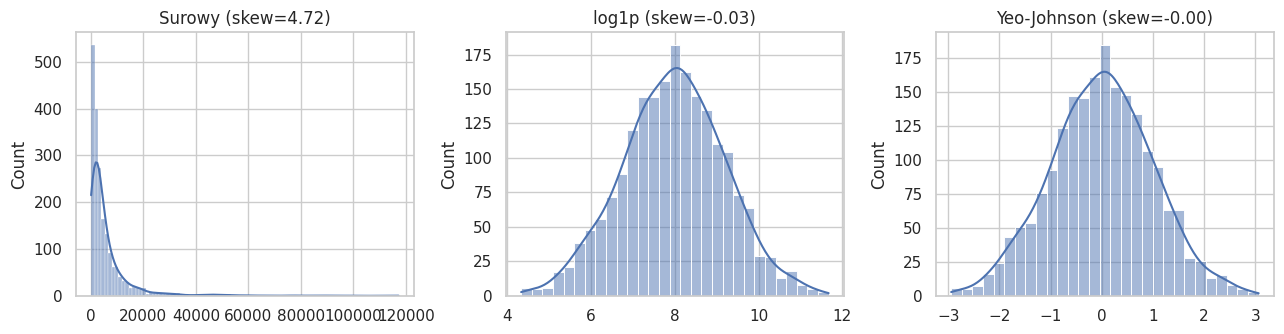

In [9]:
przychod = rng.lognormal(mean=8, sigma=1.2, size=2000)

przychod_log = np.log1p(przychod)

pt = PowerTransformer(method="yeo-johnson")
przychod_yeo = pt.fit_transform(przychod.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sns.histplot(przychod, ax=axes[0], kde=True).set_title(f"Surowy (skew={pd.Series(przychod).skew():.2f})")
sns.histplot(przychod_log, ax=axes[1], kde=True).set_title(f"log1p (skew={pd.Series(przychod_log).skew():.2f})")
sns.histplot(przychod_yeo, ax=axes[2], kde=True).set_title(f"Yeo-Johnson (skew={pd.Series(przychod_yeo).skew():.2f})")
plt.tight_layout()
plt.show()

Dla modeli opartych na drzewach (RandomForest, gradient boosting)
transformacja skośności zwykle **nie ma znaczenia** — drzewo dzieli po
wartościach progowych, nie po odległości, więc monotoniczna transformacja
(log) nie zmienia sensu podziałów. Warto ją stosować głównie pod modele
liniowe, regresję czy sieci neuronowe.

## 6. Binning (dyskretyzacja) i cechy interakcyjne

### a) Binning — kiedy warto zamienić liczbę na przedziały

Przydatne, gdy zależność z targetem jest wyraźnie nieliniowa (np. ryzyko
rośnie gwałtownie po przekroczeniu progu wieku), a model jest liniowy —
"łamie" sztywne założenie liniowości, dając modelowi osobny współczynnik
na przedział.

In [10]:
wiek = rng.integers(18, 80, 500)

# pd.cut -> przedziały o RÓWNEJ SZEROKOŚCI (albo zdefiniowanych granicach)
grupy_wieku_cut = pd.cut(wiek, bins=[18, 30, 45, 60, 80], labels=["18-30", "31-45", "46-60", "61-80"])

# pd.qcut -> przedziały o RÓWNEJ LICZEBNOŚCI (kwantyle) — przydatne gdy rozkład nierównomierny
grupy_wieku_qcut = pd.qcut(wiek, q=4, labels=["Q1", "Q2", "Q3", "Q4"])

print(grupy_wieku_cut.value_counts().sort_index())
print()
print(grupy_wieku_qcut.value_counts().sort_index())

18-30    120
31-45    106
46-60    123
61-80    140
Name: count, dtype: int64

Q1    131
Q2    122
Q3    126
Q4    121
Name: count, dtype: int64


### b) Cechy interakcyjne — kiedy iloczyn dwóch cech niesie więcej niż każda z osobna

Przykład klasyczny: `sprzedaz / liczba_dni_aktywnosci` (średnia dzienna) niesie
więcej informacji biznesowej niż same `sprzedaz` i `liczba_dni_aktywnosci`
osobno — bo model liniowy nie "wymyśli" sobie ilorazu samodzielnie.

In [11]:
df_klient_aktywnosc = pd.DataFrame({
    "sprzedaz_laczna": [12000, 3000, 8000, 15000],
    "dni_aktywnosci": [365, 30, 200, 365],
})

# ręczna cecha interakcyjna — ma jasną interpretację biznesową
df_klient_aktywnosc["srednia_dzienna_sprzedaz"] = (
    df_klient_aktywnosc["sprzedaz_laczna"] / df_klient_aktywnosc["dni_aktywnosci"]
)
df_klient_aktywnosc

,sprzedaz_laczna,dni_aktywnosci,srednia_dzienna_sprzedaz
0,12000,365,32.876712
1,3000,30,100.000000
2,8000,200,40.000000
3,15000,365,41.095890


`sklearn.preprocessing.PolynomialFeatures` generuje WSZYSTKIE iloczyny/
potęgi cech automatycznie — wygodne przy eksploracji, ale liczba nowych
kolumn rośnie bardzo szybko (kwadratowo z liczbą cech wejściowych) i
większość wygenerowanych interakcji nie ma sensu biznesowego. W praktyce
analitycznej ręcznie dobrane interakcje (jak wyżej) zwykle dają lepszy
stosunek wartości do kosztu niż automatyczne `PolynomialFeatures` na
szerokim zbiorze cech.

## 7. Outliery — wykrywanie i capping (winsorizing)

Metoda IQR (rozstęp międzykwartylowy) — punkt odniesienia z poprzedniego
notebooka o testach statystycznych (mediana/kwantyle jako miary odporne na
outliery). Zamiast usuwać wartości odstające (tracisz dane), często lepiej
je "ściąć" (capping) do granicy — zachowujesz informację "to była wysoka
wartość", tracąc tylko jej dokładną skalę.

Granice IQR: [-148.9, 509.1]
Liczba outlierów: 25


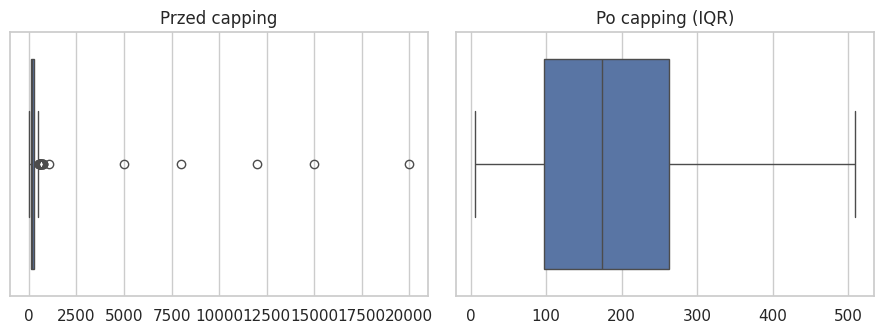

In [12]:
wartosc_koszyka = np.concatenate([rng.gamma(2, 100, 490), [5000, 8000, 12000, 15000, 20000]])  # kilka ekstremów

q1, q3 = np.percentile(wartosc_koszyka, [25, 75])
iqr = q3 - q1
dolna_granica = q1 - 1.5 * iqr
gorna_granica = q3 + 1.5 * iqr

liczba_outlierow = ((wartosc_koszyka < dolna_granica) | (wartosc_koszyka > gorna_granica)).sum()
print(f"Granice IQR: [{dolna_granica:.1f}, {gorna_granica:.1f}]")
print(f"Liczba outlierów: {liczba_outlierow}")

wartosc_koszyka_capped = np.clip(wartosc_koszyka, dolna_granica, gorna_granica)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.boxplot(x=wartosc_koszyka, ax=axes[0]).set_title("Przed capping")
sns.boxplot(x=wartosc_koszyka_capped, ax=axes[1]).set_title("Po capping (IQR)")
plt.tight_layout()
plt.show()

**Kiedy NIE ściinać outlierów:** gdy same ekstremalne wartości są tym, co
próbujesz przewidzieć/wykryć (fraud detection, awarie, bardzo duzi klienci
B2B) — tam outlier to sygnał, nie szum do wygładzenia.

## 8. Cechy przestrzenne — GeoPandas

Nawiązanie do notebooka o Folium: te same warstwy wektorowe, tym razem nie
do wizualizacji, tylko do budowy cech dla modelu — odległość do punktu
odniesienia i przynależność przestrzenna (spatial join).

In [13]:
# punkty klientów (syntetyczne współrzędne w okolicy Warszawy)
klienci_gdf = gpd.GeoDataFrame({
    "klient_id": range(1, 9),
    "geometry": [Point(21.0 + rng.uniform(-0.15, 0.15), 52.23 + rng.uniform(-0.1, 0.1)) for _ in range(8)],
}, crs="EPSG:4326")

centrum_warszawy = Point(21.0122, 52.2297)

# odległość do punktu referencyjnego — w metrach wymaga układu metrycznego (nie stopni), stąd to_crs
klienci_metryczne = klienci_gdf.to_crs(epsg=2180)   # PL-1992, układ metryczny dla Polski
centrum_metryczne = gpd.GeoSeries([centrum_warszawy], crs="EPSG:4326").to_crs(epsg=2180).iloc[0]

klienci_gdf["odleglosc_od_centrum_km"] = (klienci_metryczne.distance(centrum_metryczne) / 1000).round(2)
klienci_gdf[["klient_id", "odleglosc_od_centrum_km"]]

,klient_id,odleglosc_od_centrum_km
0,1,6.19
1,2,2.85
2,3,10.81
3,4,12.15
4,5,10.16
5,6,6.59
6,7,1.69
7,8,8.30


In [14]:
# przynależność do obszaru (spatial join) — np. przypisanie klienta do dzielnicy/strefy sprzedażowej
strefy = gpd.GeoDataFrame({
    "strefa": ["Zachodnia", "Wschodnia"],
    "geometry": [
        Point(20.9, 52.23).buffer(0.12),   # uproszczone koła zamiast realnych granic — na potrzeby przykładu
        Point(21.1, 52.23).buffer(0.12),
    ],
}, crs="EPSG:4326")

klienci_ze_strefa = gpd.sjoin(klienci_gdf, strefy, how="left", predicate="within")
klienci_ze_strefa[["klient_id", "odleglosc_od_centrum_km", "strefa"]]

,klient_id,odleglosc_od_centrum_km,strefa
0,1,6.19,Wschodnia
1,2,2.85,Wschodnia
2,3,10.81,Zachodnia
3,4,12.15,Zachodnia
4,5,10.16,Zachodnia
5,6,6.59,Wschodnia
6,7,1.69,Wschodnia
7,8,8.30,Wschodnia


Ten sam wzorzec skaluje się do prawdziwych granic administracyjnych
(województwa/powiaty z poprzedniego notebooka o Folium) — `sjoin` z
`predicate="within"` przypisuje każdemu punktowi nazwę jednostki, w której
się znajduje, gotową do dalszego one-hot/frequency encoding (sekcja 4).

## 9. Selekcja cech — mniej znaczy czasem więcej

### a) Cechy o (prawie) zerowej wariancji — nie niosą informacji

In [15]:
df_cechy = pd.DataFrame({
    "cecha_a": rng.normal(0, 1, 200),
    "cecha_b": rng.normal(0, 1, 200),
    "cecha_stala": [1] * 200,          # brak wariancji — bezużyteczna dla każdego modelu
    "cecha_prawie_stala": rng.choice([0, 0, 0, 0, 1], 200),  # prawie zawsze ta sama wartość
})

selektor = VarianceThreshold(threshold=0.05)
selektor.fit(df_cechy)

cechy_do_usuniecia = df_cechy.columns[~selektor.get_support()]
print("Cechy do usunięcia (niska wariancja):", list(cechy_do_usuniecia))

Cechy do usunięcia (niska wariancja): ['cecha_stala']


### b) Multikolinearność — VIF (Variance Inflation Factor)

Silnie skorelowane ze sobą cechy (np. `powierzchnia_m2` i `liczba_pokoi`)
"walczą" o ten sam współczynnik w modelu liniowym, czyniąc go niestabilnym
(mała zmiana danych — duża zmiana współczynników) i utrudniają interpretację
"która cecha faktycznie ma znaczenie". VIF > 5-10 to umowny sygnał problemu.

In [16]:
df_nieruchomosci = pd.DataFrame({
    "powierzchnia_m2": rng.normal(60, 20, 300),
})
df_nieruchomosci["liczba_pokoi"] = (df_nieruchomosci["powierzchnia_m2"] / 20 + rng.normal(0, 0.3, 300)).round()
df_nieruchomosci["odleglosc_od_centrum_km"] = rng.uniform(1, 20, 300)   # niepowiązana z resztą

vif_wyniki = pd.DataFrame({
    "cecha": df_nieruchomosci.columns,
    "VIF": [variance_inflation_factor(df_nieruchomosci.values, i) for i in range(df_nieruchomosci.shape[1])],
})
vif_wyniki

,cecha,VIF
0,powierzchnia_m2,6.174684
1,liczba_pokoi,6.170009
2,odleglosc_od_centrum_km,1.008387


`powierzchnia_m2` i `liczba_pokoi` (silnie skorelowane, bo `liczba_pokoi`
została policzona wprost z powierzchni) powinny wyjść z wysokim VIF —
rozwiązanie: usuń jedną z par, albo zastąp obie jedną cechą (np. średnia
powierzchnia pokoju), albo użyj modelu odpornego na współliniowość
(drzewa/lasy losowe, regularyzacja Ridge/Lasso).

## 10. Feature engineering WEWNĄTRZ Pipeline — unikanie leakage strukturalnie

Sekcja 4 pokazała target encoding z ręcznym K-Fold. W praktyce lepiej
opakować własną transformację w obiekt zgodny z API scikit-learn
(`FunctionTransformer` dla prostych, bezstanowych transformacji, klasa z
`BaseEstimator`/`TransformerMixin` dla takich, które muszą "zapamiętać"
coś z danych treningowych) — wtedy `Pipeline`/`cross_val_score` z
poprzedniego notebooka automatycznie pilnuje poprawnej kolejności fit/transform,
tak samo jak dla `StandardScaler`.

In [17]:
# prosta, bezstanowa transformacja (nie wymaga 'uczenia się' z danych) -> FunctionTransformer wystarczy
def dodaj_cechy_czasowe(X):
    X = X.copy()
    X["miesiac_sin"] = np.sin(2 * np.pi * X["miesiac"] / 12)
    X["miesiac_cos"] = np.cos(2 * np.pi * X["miesiac"] / 12)
    return X.drop(columns=["miesiac"])

transformer_czasowy = FunctionTransformer(dodaj_cechy_czasowe)

przyklad = pd.DataFrame({"miesiac": [1, 6, 12], "wartosc": [10, 20, 30]})
transformer_czasowy.transform(przyklad)

,wartosc,miesiac_sin,miesiac_cos
0,10,5.000000e-01,0.866025
1,20,1.224647e-16,-1.000000
2,30,-2.449294e-16,1.000000


In [18]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoderKFold(BaseEstimator, TransformerMixin):
    """
    Target encoding, który 'uczy się' średnich TYLKO na danych przekazanych
    do fit() — dzięki temu w Pipeline/cross_val_score automatycznie liczy
    średnie osobno w każdym foldzie treningowym, bez ręcznej pętli z sekcji 4.
    Jedyna klasa w tym notebooku warta trzymania jako współdzielony kod —
    ta sama logika wraca w każdym projekcie z kategoriami wysokiej kardynalności.
    """

    def __init__(self, kolumna: str):
        self.kolumna = kolumna

    def fit(self, X, y):
        self.mapowanie_ = pd.Series(y).groupby(X[self.kolumna].values).mean()
        self.srednia_globalna_ = pd.Series(y).mean()   # fallback dla kategorii nieobecnych w treningu
        return self

    def transform(self, X):
        X = X.copy()
        X[f"{self.kolumna}_target_encoded"] = (
            X[self.kolumna].map(self.mapowanie_).fillna(self.srednia_globalna_)
        )
        return X.drop(columns=[self.kolumna])


encoder = TargetEncoderKFold(kolumna="segment")
encoder.fit(df_target[["segment"]], df_target["churn"])
encoder.transform(df_target[["segment"]]).head()

,segment_target_encoded
0,0.666667
1,0.250000
2,0.285714
3,0.600000
4,0.500000


## Podsumowanie

| Typ cechy | Technika | Uwaga |
|---|---|---|
| Data | komponenty (rok/miesiąc/dzień) + kodowanie cykliczne sin/cos | cykliczność ważna głównie dla modeli liniowych/odległościowych |
| "Czas od zdarzenia" | różnica względem STAŁEJ daty odniesienia | nigdy względem daty systemowej w produkcji |
| Kategoryczna, mało poziomów | one-hot | z poprzedniego notebooka |
| Kategoryczna, dużo poziomów | frequency / target encoding | target encoding TYLKO z K-Fold (sekcja 4, 10) |
| Numeryczna, skośna | log1p / PowerTransformer | głównie pod modele liniowe, drzewom obojętne |
| Numeryczna, zależność nieliniowa | binning (`pd.cut`/`qcut`) | głównie pod modele liniowe |
| Dwie powiązane cechy | interakcja ręczna (iloraz/iloczyn) | lepsza niż automatyczny `PolynomialFeatures` na szeroką skalę |
| Współrzędne | odległość do punktu, spatial join | wymaga układu metrycznego (`to_crs`) do odległości w metrach |
| Cała lista cech | `VarianceThreshold`, VIF, korelacja z targetem | usuwaj przed modelowaniem, nie po |

Najważniejsza zasada spinająca cały notebook: każda transformacja, która
"uczy się" czegoś z danych (średnia, mapowanie kategorii, parametry
transformacji) musi być dopasowana (`fit`) WYŁĄCZNIE na danych
treningowych — najlepiej jako krok w `Pipeline`, nie jako ręczna operacja
na całym DataFrame przed podziałem train/test.